In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE

from lightgbm import LGBMClassifier
import shap
import joblib


In [26]:
df = pd.read_csv("indian_liver_patient.csv")

In [27]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Dataset"] = df["Dataset"].map({1: 1, 2: 0})

In [28]:
imputer = SimpleImputer(strategy="median")
df.iloc[:, :] = imputer.fit_transform(df)

In [29]:
X = df.drop("Dataset", axis=1)
y = df["Dataset"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [32]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=rf,
    n_features_to_select=6
)

X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe  = rfe.transform(X_test_scaled)


In [33]:
smote_enn = SMOTEENN(random_state=42)

X_train_bal_enn, y_train_bal_enn = smote_enn.fit_resample(
    X_train_scaled, y_train
)

In [34]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled, y_train
)

print("Balanced distribution:", np.bincount(y_train_bal))

Balanced distribution: [333 333]


In [35]:
final_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight={0:1, 1:2},
    random_state=42
)

final_model.fit(X_train_bal, y_train_bal)


[LightGBM] [Info] Number of positive: 333, number of negative: 333
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1262
[LightGBM] [Info] Number of data points in the train set: 666, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666667 -> initscore=0.693147
[LightGBM] [Info] Start training from score 0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,"{0: 1, 1: 2}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [36]:
preds = final_model.predict(X_test_scaled)

print(classification_report(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

              precision    recall  f1-score   support

           0       0.58      0.32      0.42        34
           1       0.77      0.90      0.83        83

    accuracy                           0.74       117
   macro avg       0.67      0.61      0.62       117
weighted avg       0.71      0.74      0.71       117

Confusion Matrix:
 [[11 23]
 [ 8 75]]


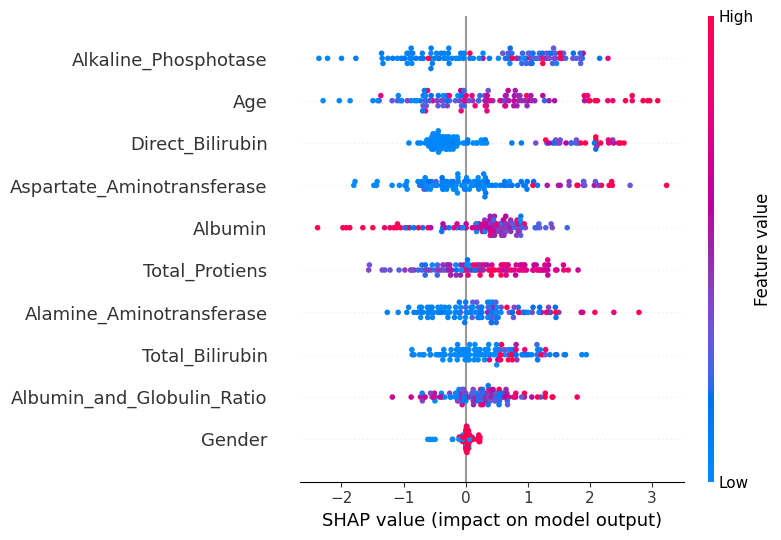

In [38]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

In [51]:
joblib.dump(final_model, "lightgbm_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(imputer, "imputer.pkl")

['imputer.pkl']